# Calculated Feature Table EDA

This notebook picks up after `integrated_monthly_base_eda.ipynb`. The integrated monthly source data has already been joined, normalized, and validated; this notebook explores the next pipeline stage: the calculated H3 feature table used by the modeling experiments.

Focus areas:

- Confirm feature table shape, date coverage, target alignment, and row loss from lag/target creation.
- Inventory calculated feature groups and feature-family definitions.
- Inspect missingness, imputation flags, and regime/time features.
- Compare distributions and time-series behavior for representative calculated features.
- Screen correlations with the three-month-ahead UPT target and identify highly correlated feature pairs.

In [ ]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

FEATURE_DIR = Path("feature_store/income_interactions_h3_v1")
FEATURE_TABLE_PATH = FEATURE_DIR / "feature_table.parquet"
FEATURE_FAMILIES_PATH = FEATURE_DIR / "feature_families.json"
FEATURE_AUDIT_PATH = FEATURE_DIR / "feature_family_audit.parquet"
FEATURE_METADATA_PATH = FEATURE_DIR / "feature_metadata.json"
IMPUTATION_LOG_PATH = FEATURE_DIR / "imputation_log.parquet"
INTEGRATED_BASE_PATH = Path("raw_files/integrated_monthly_base.parquet")

HORIZON = 3
TARGET_COL = f"upt_target_h{HORIZON}"
DATE_COL = "date"

for path in [FEATURE_TABLE_PATH, FEATURE_FAMILIES_PATH, FEATURE_METADATA_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

## Load Artifacts

The notebook defaults to the same income-aware H3 feature table used by the current experiment configs. Paths are intentionally centralized above so this can be pointed at another feature-store run later.

In [ ]:
feature_df = pd.read_parquet(FEATURE_TABLE_PATH).copy()
feature_df[DATE_COL] = pd.to_datetime(feature_df[DATE_COL]).dt.to_period("M").dt.to_timestamp()

with open(FEATURE_FAMILIES_PATH, "r") as file:
    feature_families = json.load(file)

feature_audit = pd.read_parquet(FEATURE_AUDIT_PATH) if FEATURE_AUDIT_PATH.exists() else pd.DataFrame()
feature_metadata = json.loads(FEATURE_METADATA_PATH.read_text())
imputation_log = pd.read_parquet(IMPUTATION_LOG_PATH) if IMPUTATION_LOG_PATH.exists() else pd.DataFrame()
integrated_base = pd.read_parquet(INTEGRATED_BASE_PATH) if INTEGRATED_BASE_PATH.exists() else pd.DataFrame()
if not integrated_base.empty and DATE_COL in integrated_base.columns:
    integrated_base[DATE_COL] = pd.to_datetime(integrated_base[DATE_COL]).dt.to_period("M").dt.to_timestamp()

artifact_summary = pd.DataFrame(
    [
        {"artifact": "feature_table", "path": str(FEATURE_TABLE_PATH), "rows": len(feature_df), "columns": feature_df.shape[1]},
        {"artifact": "feature_families", "path": str(FEATURE_FAMILIES_PATH), "rows": len(feature_families), "columns": None},
        {"artifact": "feature_family_audit", "path": str(FEATURE_AUDIT_PATH), "rows": len(feature_audit), "columns": feature_audit.shape[1] if not feature_audit.empty else None},
        {"artifact": "imputation_log", "path": str(IMPUTATION_LOG_PATH), "rows": len(imputation_log), "columns": imputation_log.shape[1] if not imputation_log.empty else None},
        {"artifact": "integrated_base", "path": str(INTEGRATED_BASE_PATH), "rows": len(integrated_base), "columns": integrated_base.shape[1] if not integrated_base.empty else None},
    ]
)
artifact_summary

,artifact,path,rows,columns
0,feature_table,feature_store/income_interactions_h3_v1/feature_table.parquet,275,165.0000
1,feature_families,feature_store/income_interactions_h3_v1/feature_families.json,21,NaN
2,feature_family_audit,feature_store/income_interactions_h3_v1/feature_family_audit.parquet,21,4.0000
3,imputation_log,feature_store/income_interactions_h3_v1/imputation_log.parquet,0,NaN
4,integrated_base,raw_files/integrated_monthly_base.parquet,291,21.0000


In [3]:
metadata_summary = {
    "created_at_utc": feature_metadata.get("created_at_utc"),
    "run_id": feature_metadata.get("run_id"),
    "horizon": feature_metadata.get("horizon"),
    "date_min": feature_metadata.get("continuity", {}).get("date_min"),
    "date_max": feature_metadata.get("continuity", {}).get("date_max"),
    "row_count": feature_metadata.get("continuity", {}).get("row_count"),
    "missing_month_count": feature_metadata.get("continuity", {}).get("missing_month_count"),
    "target_null_count": feature_metadata.get("feature_table", {}).get("target_null_count"),
}
pd.Series(metadata_summary, name="feature_metadata")

,feature_metadata
created_at_utc,2026-06-06T22:35:16.817294+00:00
run_id,2026-06-06T22-35-16Z
horizon,3
date_min,2003-05-01
date_max,2026-03-01
row_count,275
missing_month_count,0
target_null_count,3


## Feature Table Shape And Target Alignment

The calculated table starts later than the integrated base because lagged and rolling features need historical lookback. The H3 target also creates missing target values at the final three rows, because future UPT is not yet observed for those target months.

In [4]:
coverage_rows = []
if not integrated_base.empty:
    coverage_rows.append(
        {
            "stage": "integrated_monthly_base",
            "rows": len(integrated_base),
            "columns": integrated_base.shape[1],
            "date_min": integrated_base[DATE_COL].min(),
            "date_max": integrated_base[DATE_COL].max(),
            "target_nulls": np.nan,
        }
    )
coverage_rows.append(
    {
        "stage": "calculated_feature_table",
        "rows": len(feature_df),
        "columns": feature_df.shape[1],
        "date_min": feature_df[DATE_COL].min(),
        "date_max": feature_df[DATE_COL].max(),
        "target_nulls": int(feature_df[TARGET_COL].isna().sum()) if TARGET_COL in feature_df else np.nan,
    }
)
coverage_summary = pd.DataFrame(coverage_rows)
coverage_summary

,stage,rows,columns,date_min,date_max,target_nulls
0,integrated_monthly_base,291,21,2002-01-01,2026-03-01,NaN
1,calculated_feature_table,275,165,2003-05-01,2026-03-01,3.0000


In [5]:
target_alignment = feature_df[[DATE_COL, "upt", TARGET_COL, f"target_date_h{HORIZON}"]].copy()
target_alignment[f"target_date_h{HORIZON}"] = pd.to_datetime(target_alignment[f"target_date_h{HORIZON}"])
target_alignment["target_date_delta_months"] = (
    (target_alignment[f"target_date_h{HORIZON}"].dt.year - target_alignment[DATE_COL].dt.year) * 12
    + (target_alignment[f"target_date_h{HORIZON}"].dt.month - target_alignment[DATE_COL].dt.month)
)
target_alignment.tail(10)

,date,upt,upt_target_h3,target_date_h3,target_date_delta_months
265,2025-06-01,"6,688,867.0000","6,597,525.0000",2025-09-01,3
266,2025-07-01,"6,716,230.0000","7,027,582.0000",2025-10-01,3
267,2025-08-01,"6,629,625.0000","6,034,095.0000",2025-11-01,3
268,2025-09-01,"6,597,525.0000","5,848,180.0000",2025-12-01,3
269,2025-10-01,"7,027,582.0000","6,315,539.0000",2026-01-01,3
270,2025-11-01,"6,034,095.0000","5,912,095.0000",2026-02-01,3
271,2025-12-01,"5,848,180.0000","6,646,228.0000",2026-03-01,3
272,2026-01-01,"6,315,539.0000",NaN,2026-04-01,3
273,2026-02-01,"5,912,095.0000",NaN,2026-05-01,3
274,2026-03-01,"6,646,228.0000",NaN,2026-06-01,3


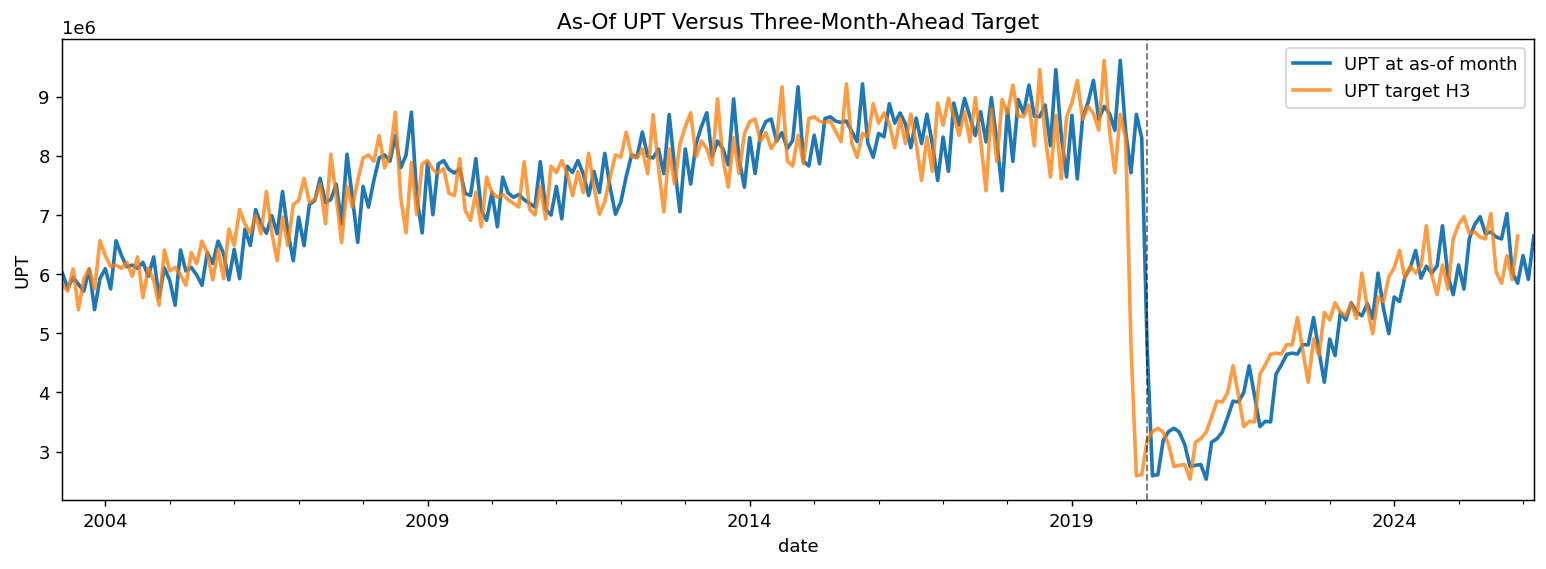

In [6]:
fig, ax = plt.subplots(figsize=(12, 4.5))
plot_df = target_alignment.set_index(DATE_COL)
plot_df["upt"].plot(ax=ax, label="UPT at as-of month", linewidth=2)
plot_df[TARGET_COL].plot(ax=ax, label=f"UPT target H{HORIZON}", linewidth=2, alpha=0.78)
ax.axvline(pd.Timestamp("2020-03-01"), color="black", linestyle="--", linewidth=1, alpha=0.55)
ax.set_title("As-Of UPT Versus Three-Month-Ahead Target")
ax.set_ylabel("UPT")
ax.legend(loc="best")
plt.tight_layout()

**Target-alignment takeaway:** the feature table keeps the as-of month and the future target month in the same row. Features must be interpreted as what is known at the as-of date, while `upt_target_h3` is the value to forecast three months later.

## Feature Inventory

The feature table includes raw integrated source columns plus calculated time, regime, lag, rolling, exogenous, income, interaction, and target-context columns. This inventory is a first pass at checking whether the feature explosion matches the intended modeling design.

In [7]:
BASE_SOURCE_COLS = {
    "date", "upt", "vrm", "vrh", "voms",
    "seattle_gas_price_avg", "seattle_gas_price_std",
    "cpi_all_items_sa", "cpi_core_sa",
    "income_reference_year",
    "king_county_median_household_income_prior_year",
    "king_county_monthly_household_income_prior_year",
    "king_county_income_yoy_pct_prior_year",
    "king_county_income_2yr_pct_prior_year",
}
TARGET_CONTEXT_PATTERNS = ("target_",)

def feature_category(col: str) -> str:
    if col in {DATE_COL, TARGET_COL} or col.startswith(TARGET_CONTEXT_PATTERNS):
        return "target_context"
    if col in BASE_SOURCE_COLS:
        return "base_source"
    if "imputed" in col or col.endswith("_was_imputed"):
        return "imputation_flag"
    if col.startswith("month_") or col in {"time_index_months", "month_num"}:
        return "time_seasonality"
    if "pandemic" in col or "covid" in col:
        return "regime"
    if "_x_" in col:
        return "interaction"
    if "roll" in col:
        return "rolling"
    if "_lag" in col:
        return "lag"
    if "_diff" in col or "yoy" in col:
        return "change_rate"
    if "income" in col:
        return "income"
    if "gas" in col or "cpi" in col:
        return "exogenous"
    return "other"

feature_inventory = pd.DataFrame(
    {
        "column": feature_df.columns,
        "category": [feature_category(col) for col in feature_df.columns],
        "dtype": [str(feature_df[col].dtype) for col in feature_df.columns],
        "missing_count": [int(feature_df[col].isna().sum()) for col in feature_df.columns],
        "missing_pct": [float(feature_df[col].isna().mean()) for col in feature_df.columns],
        "n_unique": [int(feature_df[col].nunique(dropna=True)) for col in feature_df.columns],
    }
)
feature_inventory.groupby("category").agg(
    columns=("column", "count"),
    missing_columns=("missing_count", lambda x: int((x > 0).sum())),
    max_missing_pct=("missing_pct", "max"),
).sort_values("columns", ascending=False)

,columns,missing_columns,max_missing_pct
category,,,
lag,63,63,0.0873
regime,37,24,0.0473
rolling,14,14,0.0218
base_source,13,0,0.0000
imputation_flag,12,0,0.0000
change_rate,8,8,0.0473
time_seasonality,8,0,0.0000
target_context,6,1,0.0109
interaction,3,3,0.0473


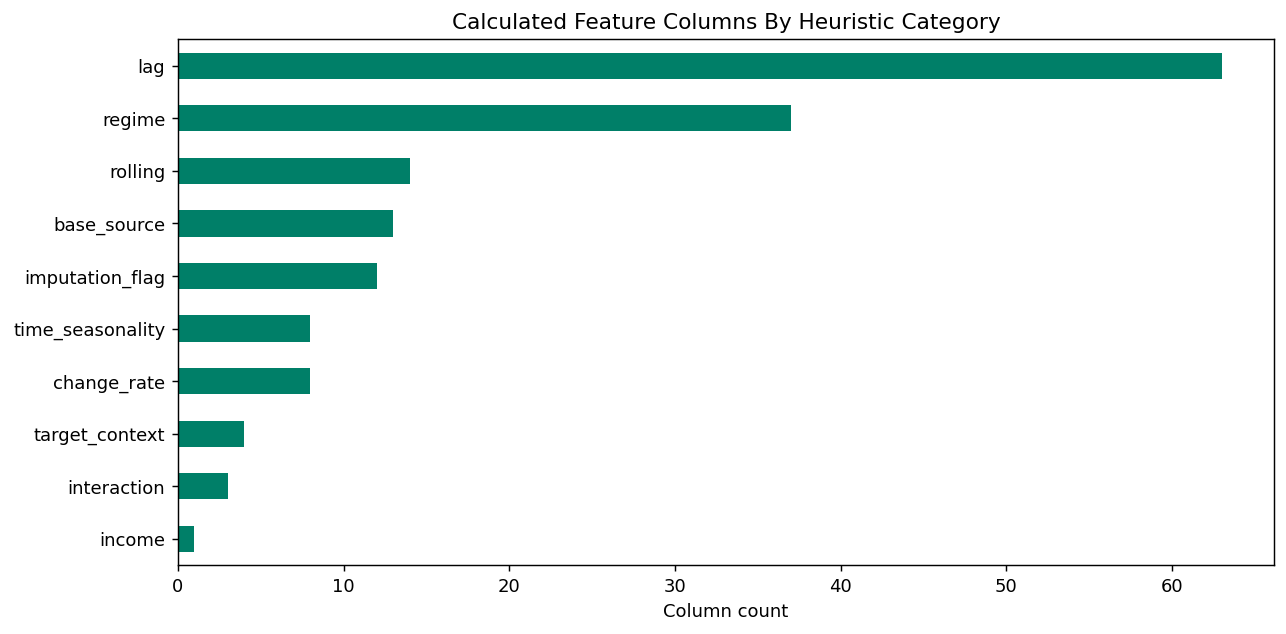

In [8]:
category_counts = feature_inventory[~feature_inventory["column"].isin([DATE_COL, TARGET_COL])].groupby("category")["column"].count().sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
category_counts.plot(kind="barh", ax=ax, color="#007f68")
ax.set_title("Calculated Feature Columns By Heuristic Category")
ax.set_xlabel("Column count")
ax.set_ylabel("")
plt.tight_layout()

In [9]:
feature_inventory.sort_values(["category", "column"]).head(60)

,column,category,dtype,missing_count,missing_pct,n_unique
7,cpi_all_items_sa,base_source,float64,0,0.0000,269
8,cpi_core_sa,base_source,float64,0,0.0000,274
9,income_reference_year,base_source,int32,0,0.0000,24
13,king_county_income_2yr_pct_prior_year,base_source,float64,0,0.0000,24
12,king_county_income_yoy_pct_prior_year,base_source,float64,0,0.0000,24
10,king_county_median_household_income_prior_year,base_source,float64,0,0.0000,24
11,king_county_monthly_household_income_prior_year,base_source,float64,0,0.0000,24
5,seattle_gas_price_avg,base_source,float64,0,0.0000,275
6,seattle_gas_price_std,base_source,float64,0,0.0000,275
1,upt,base_source,float64,0,0.0000,275


## Feature Families

Feature families define modeling hypotheses. Some are compact historical baselines, while later families add regimes, exogenous signals, service context, income, and interaction terms.

In [10]:
family_summary = pd.DataFrame(
    [
        {
            "feature_family": family,
            "feature_count": len(features),
            "available_features": sum(feature in feature_df.columns for feature in features),
            "missing_features": [feature for feature in features if feature not in feature_df.columns],
        }
        for family, features in feature_families.items()
    ]
).sort_values("feature_count")
family_summary.assign(missing_feature_count=lambda x: x["missing_features"].map(len)).head(25)

,feature_family,feature_count,available_features,missing_features,missing_feature_count
0,history_only,11,11,[],0
1,history_recent,14,14,[],0
2,history_rolls,18,18,[],0
3,history_full,19,19,[],0
4,history_regime,23,23,[],0
5,history_regime_time,24,24,[],0
18,history_regime_income,27,27,[],0
20,history_regime_income_linear_interactions,31,31,[],0
14,history_regime_linear_interactions,33,33,[],0
15,history_regime_time_linear_interactions,40,40,[],0


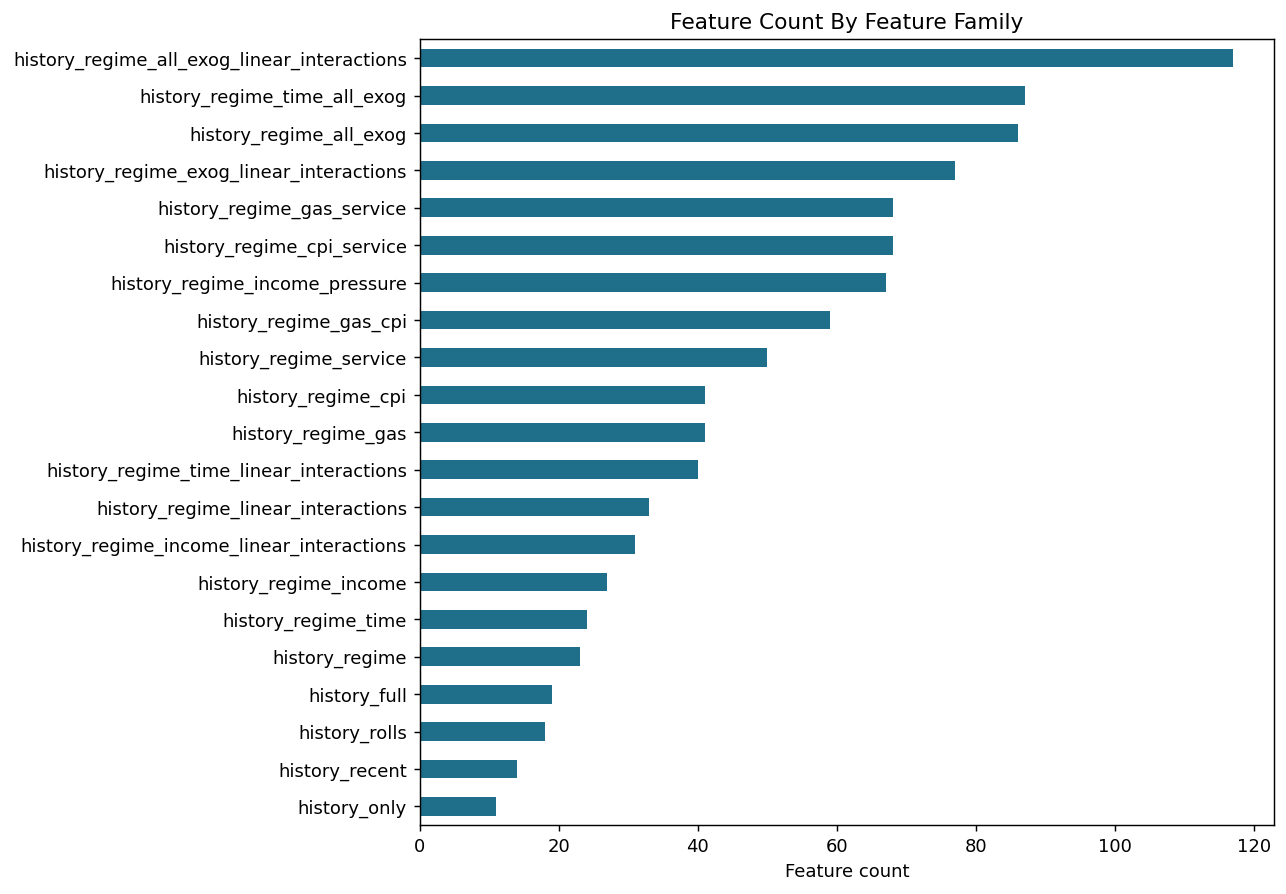

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
family_summary.set_index("feature_family")["feature_count"].plot(kind="barh", ax=ax, color="#1f6f8b")
ax.set_title("Feature Count By Feature Family")
ax.set_xlabel("Feature count")
ax.set_ylabel("")
plt.tight_layout()

In [12]:
if not feature_audit.empty:
    audit_sort_col = "requested_features" if "requested_features" in feature_audit.columns else feature_audit.columns[1]
    feature_audit.sort_values(audit_sort_col).head(25)
else:
    family_summary.head(25)

## Missingness And Imputation Flags

This section checks whether calculated features introduce unexpected gaps and whether source-level imputation flags are active. Expected target missingness at the final horizon rows is not a modeling bug; it simply indicates the future target is unavailable.

In [13]:
missing_summary = (
    feature_inventory.loc[feature_inventory["missing_count"] > 0]
    .sort_values("missing_pct", ascending=False)
    .reset_index(drop=True)
)
missing_summary.head(40)

,column,category,dtype,missing_count,missing_pct,n_unique
0,upt_lag24,lag,float64,24,0.0873,251
1,upt_lag18,lag,float64,18,0.0655,257
2,upt_yoy_diff_x_post_pandemic_observed,regime,float64,13,0.0473,62
3,seattle_gas_price_avg_yoy_diff_x_pandemic_disruption_active,regime,float64,13,0.0473,13
4,seattle_gas_price_avg_yoy_diff_x_post_pandemic_observed,regime,float64,13,0.0473,62
5,upt_yoy_diff,change_rate,float64,13,0.0473,262
6,vrm_yoy_diff,change_rate,float64,13,0.0473,254
7,cpi_core_sa_yoy_diff_x_pandemic_disruption_active,regime,float64,13,0.0473,12
8,cpi_core_sa_yoy_diff_x_post_pandemic_observed,regime,float64,13,0.0473,62
9,seattle_gas_price_std_yoy_diff,change_rate,float64,13,0.0473,262


In [14]:
imputation_cols = [col for col in feature_df.columns if "imputed" in col or col.endswith("_was_imputed")]
imputation_summary = pd.DataFrame(
    [
        {
            "imputation_column": col,
            "active_rows": int(pd.to_numeric(feature_df[col], errors="coerce").fillna(0).sum()),
            "active_pct": float(pd.to_numeric(feature_df[col], errors="coerce").fillna(0).mean()),
        }
        for col in imputation_cols
    ]
).sort_values("active_rows", ascending=False)
imputation_summary

,imputation_column,active_rows,active_pct
0,seattle_gas_price_avg_was_imputed,0,0.0000
1,seattle_gas_price_avg_imputed_interpolated,0,0.0000
2,seattle_gas_price_avg_imputed_trailing_trend,0,0.0000
3,seattle_gas_price_std_was_imputed,0,0.0000
4,seattle_gas_price_std_imputed_interpolated,0,0.0000
5,seattle_gas_price_std_imputed_trailing_trend,0,0.0000
6,cpi_all_items_sa_was_imputed,0,0.0000
7,cpi_all_items_sa_imputed_interpolated,0,0.0000
8,cpi_all_items_sa_imputed_trailing_trend,0,0.0000
9,cpi_core_sa_was_imputed,0,0.0000


In [15]:
if not imputation_log.empty:
    imputation_log.head(40)
else:
    pd.DataFrame({"note": ["No imputation log artifact found."]})

## Representative Feature Time Series

These plots help inspect whether calculated features behave as expected over time. They are intentionally representative rather than exhaustive.

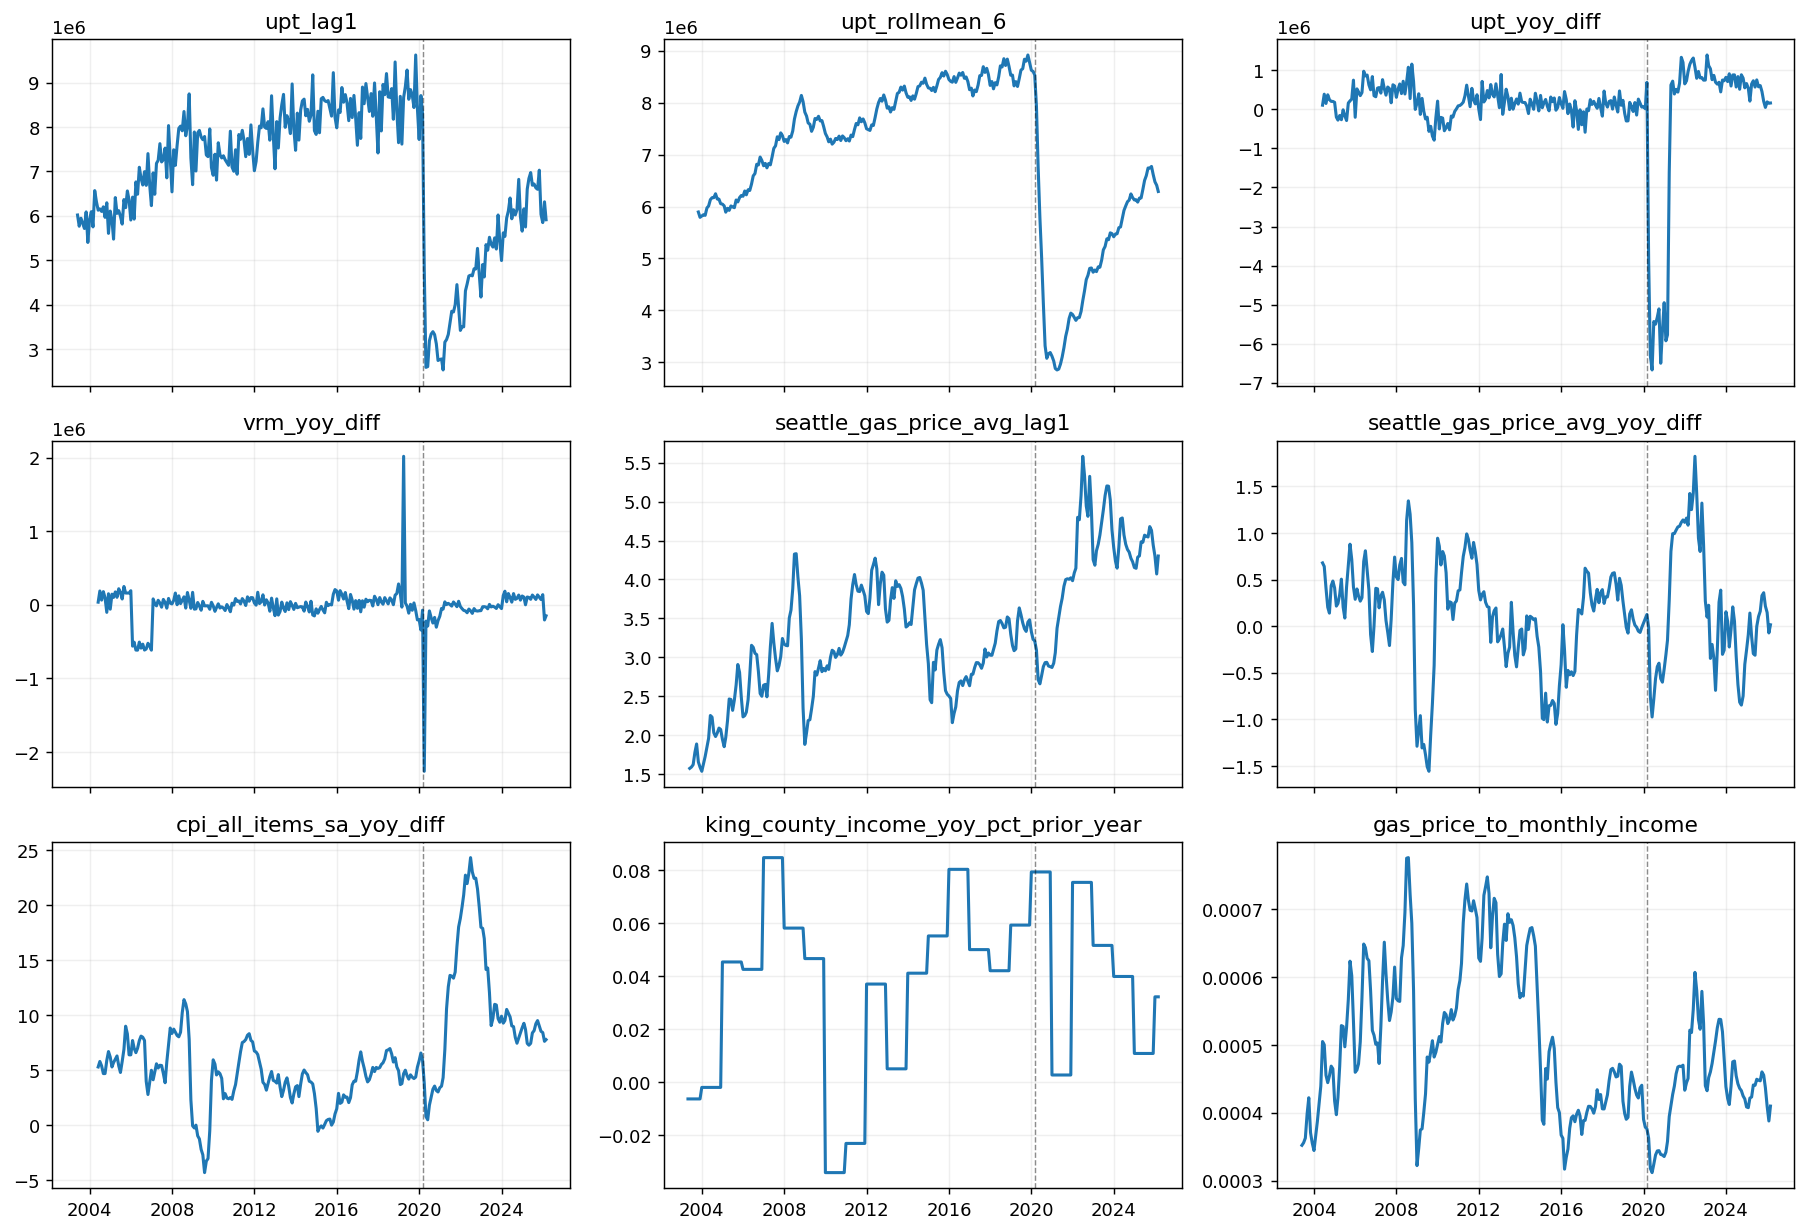

In [16]:
representative_features = [
    "upt_lag1",
    "upt_rollmean_6",
    "upt_yoy_diff",
    "vrm_yoy_diff",
    "seattle_gas_price_avg_lag1",
    "seattle_gas_price_avg_yoy_diff",
    "cpi_all_items_sa_yoy_diff",
    "king_county_income_yoy_pct_prior_year",
    "gas_price_to_monthly_income",
]
representative_features = [col for col in representative_features if col in feature_df.columns]

ncols = 3
nrows = int(np.ceil(len(representative_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, representative_features):
    ax.plot(feature_df[DATE_COL], feature_df[col], linewidth=1.7)
    ax.axvline(pd.Timestamp("2020-03-01"), color="black", linestyle="--", linewidth=0.8, alpha=0.45)
    ax.set_title(col)
    ax.grid(True, alpha=0.2)
for ax in axes[len(representative_features):]:
    ax.axis("off")
plt.tight_layout()

## Distribution Checks

Feature scaling differs dramatically across raw lags, rolling values, percent changes, indicators, and interactions. These distribution checks help flag features that might need scaling-sensitive treatment or winsorization in some model families.

In [17]:
numeric_cols = feature_df.select_dtypes(include=[np.number]).columns.tolist()
non_target_numeric = [col for col in numeric_cols if col not in {TARGET_COL} and not col.startswith("target_")]

distribution_summary = feature_df[non_target_numeric].agg(["mean", "std", "min", "median", "max"]).T
# Add robust spread for outlier screening.
q1 = feature_df[non_target_numeric].quantile(0.25)
q3 = feature_df[non_target_numeric].quantile(0.75)
distribution_summary["iqr"] = q3 - q1
distribution_summary["abs_max"] = feature_df[non_target_numeric].abs().max()
distribution_summary = distribution_summary.join(feature_inventory.set_index("column")[["category"]], how="left")
distribution_summary.sort_values("abs_max", ascending=False).head(30)

,mean,std,min,median,max,iqr,abs_max,category
upt,"6,911,341.0509","1,595,642.0697","2,532,122.0000","7,262,000.0000","9,619,655.0000","2,152,374.0000","9,619,655.0000",base_source
upt_lag12_x_pandemic_disruption_active,"396,337.3194","1,818,737.8976",0.0000,0.0000,"9,619,655.0000",0.0000,"9,619,655.0000",regime
upt_lag3,"6,918,179.8787","1,602,797.0148","2,532,122.0000","7,285,217.0000","9,619,655.0000","2,169,434.7500","9,619,655.0000",lag
upt_lag4,"6,922,128.2177","1,604,436.6346","2,532,122.0000","7,303,003.0000","9,619,655.0000","2,170,120.0000","9,619,655.0000",lag
upt_lag5,"6,925,417.2296","1,606,500.5530","2,532,122.0000","7,303,825.0000","9,619,655.0000","2,178,213.0000","9,619,655.0000",lag
upt_lag6,"6,925,037.4349","1,609,482.8208","2,532,122.0000","7,304,647.0000","9,619,655.0000","2,186,306.0000","9,619,655.0000",lag
upt_lag7,"6,926,259.4963","1,612,368.9763","2,532,122.0000","7,304,810.0000","9,619,655.0000","2,194,271.5000","9,619,655.0000",lag
upt_lag8,"6,927,370.4869","1,615,294.1264","2,532,122.0000","7,304,973.0000","9,619,655.0000","2,202,237.0000","9,619,655.0000",lag
upt_lag9,"6,928,164.2481","1,618,286.8097","2,532,122.0000","7,318,142.5000","9,619,655.0000","2,210,202.5000","9,619,655.0000",lag
upt_lag10,"6,929,067.2566","1,621,281.7055","2,532,122.0000","7,331,312.0000","9,619,655.0000","2,218,168.0000","9,619,655.0000",lag


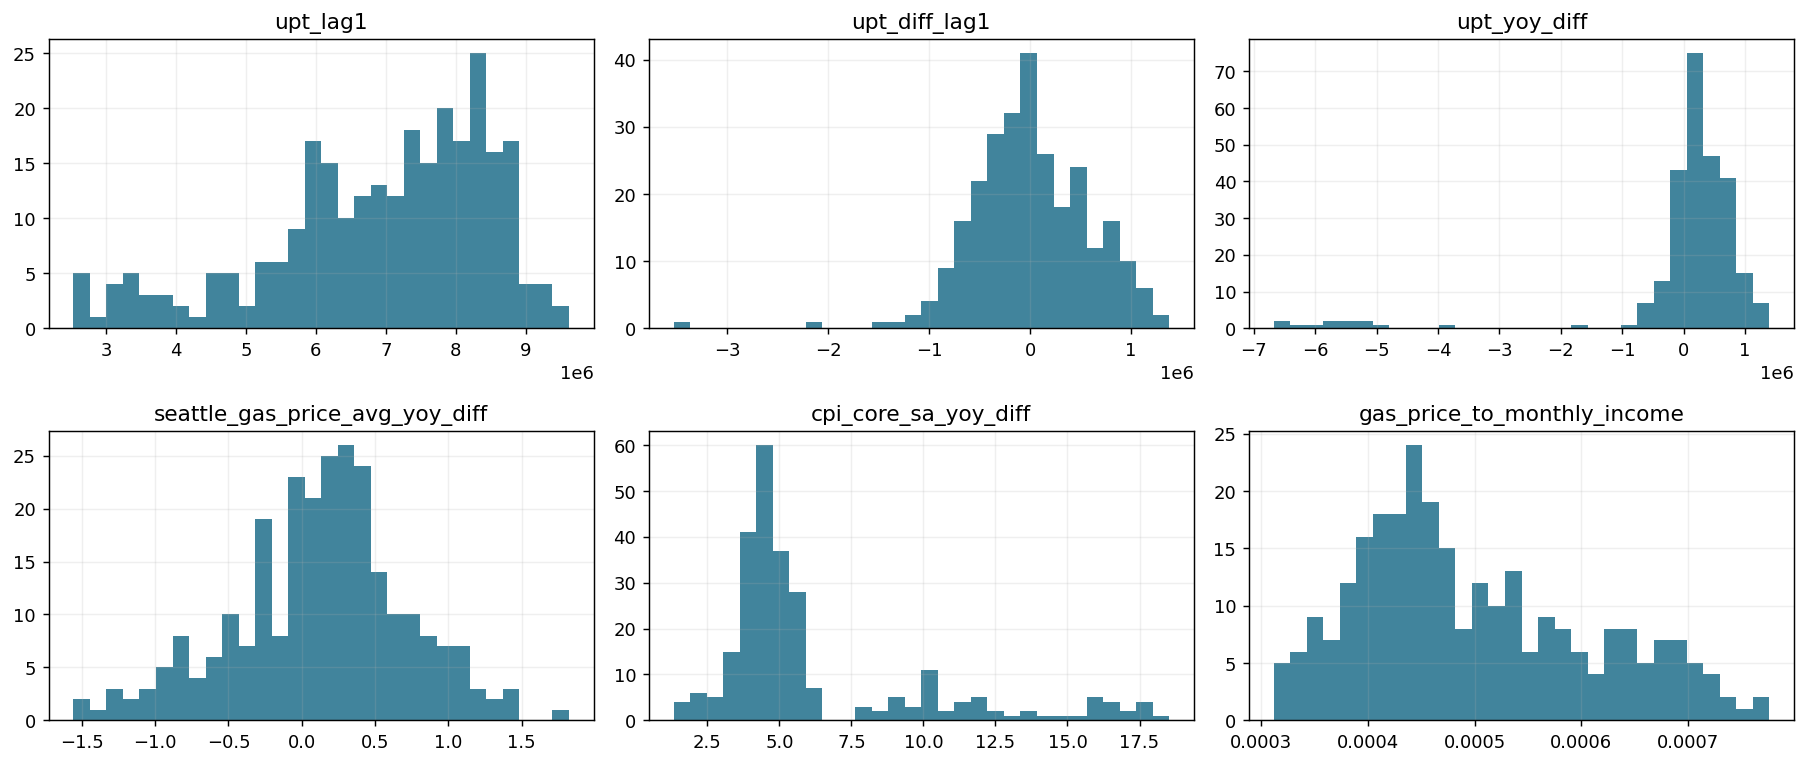

In [18]:
plot_dist_features = [
    "upt_lag1",
    "upt_diff_lag1",
    "upt_yoy_diff",
    "seattle_gas_price_avg_yoy_diff",
    "cpi_core_sa_yoy_diff",
    "gas_price_to_monthly_income",
]
plot_dist_features = [col for col in plot_dist_features if col in feature_df.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.ravel()
for ax, col in zip(axes, plot_dist_features):
    feature_df[col].dropna().hist(ax=ax, bins=30, color="#1f6f8b", alpha=0.85)
    ax.set_title(col)
    ax.grid(True, alpha=0.2)
for ax in axes[len(plot_dist_features):]:
    ax.axis("off")
plt.tight_layout()

## Relationship To H3 Target

This is a screening view, not feature selection. Correlations are useful for surfacing candidate signals and potential leakage concerns, but model evaluation still needs the rolling as-of framework.

In [19]:
modelable = feature_df.dropna(subset=[TARGET_COL]).copy()
feature_cols = [
    col for col in non_target_numeric
    if col not in {"upt"} and modelable[col].notna().sum() >= 30 and modelable[col].nunique(dropna=True) > 1
]

target_corr_rows = []
for col in feature_cols:
    aligned = modelable[[col, TARGET_COL]].dropna()
    if len(aligned) >= 30:
        target_corr_rows.append(
            {
                "feature": col,
                "category": feature_category(col),
                "corr_with_target": aligned[col].corr(aligned[TARGET_COL]),
                "n": len(aligned),
            }
        )

target_corr = pd.DataFrame(target_corr_rows)
target_corr["abs_corr"] = target_corr["corr_with_target"].abs()
target_corr.sort_values("abs_corr", ascending=False).head(40).round(4)

,feature,category,corr_with_target,n,abs_corr
40,upt_rollmean_3,rolling,0.8487,269,0.8487
23,upt_lag1,lag,0.8418,271,0.8418
24,upt_lag2,lag,0.8352,270,0.8352
42,upt_rollmean_6,rolling,0.8240,266,0.8240
25,upt_lag3,lag,0.8038,269,0.8038
26,upt_lag4,lag,0.7830,268,0.7830
27,upt_lag5,lag,0.7401,267,0.7401
28,upt_lag6,lag,0.7284,266,0.7284
16,pandemic_observed,regime,-0.7080,272,0.7080
29,upt_lag7,lag,0.6960,265,0.6960


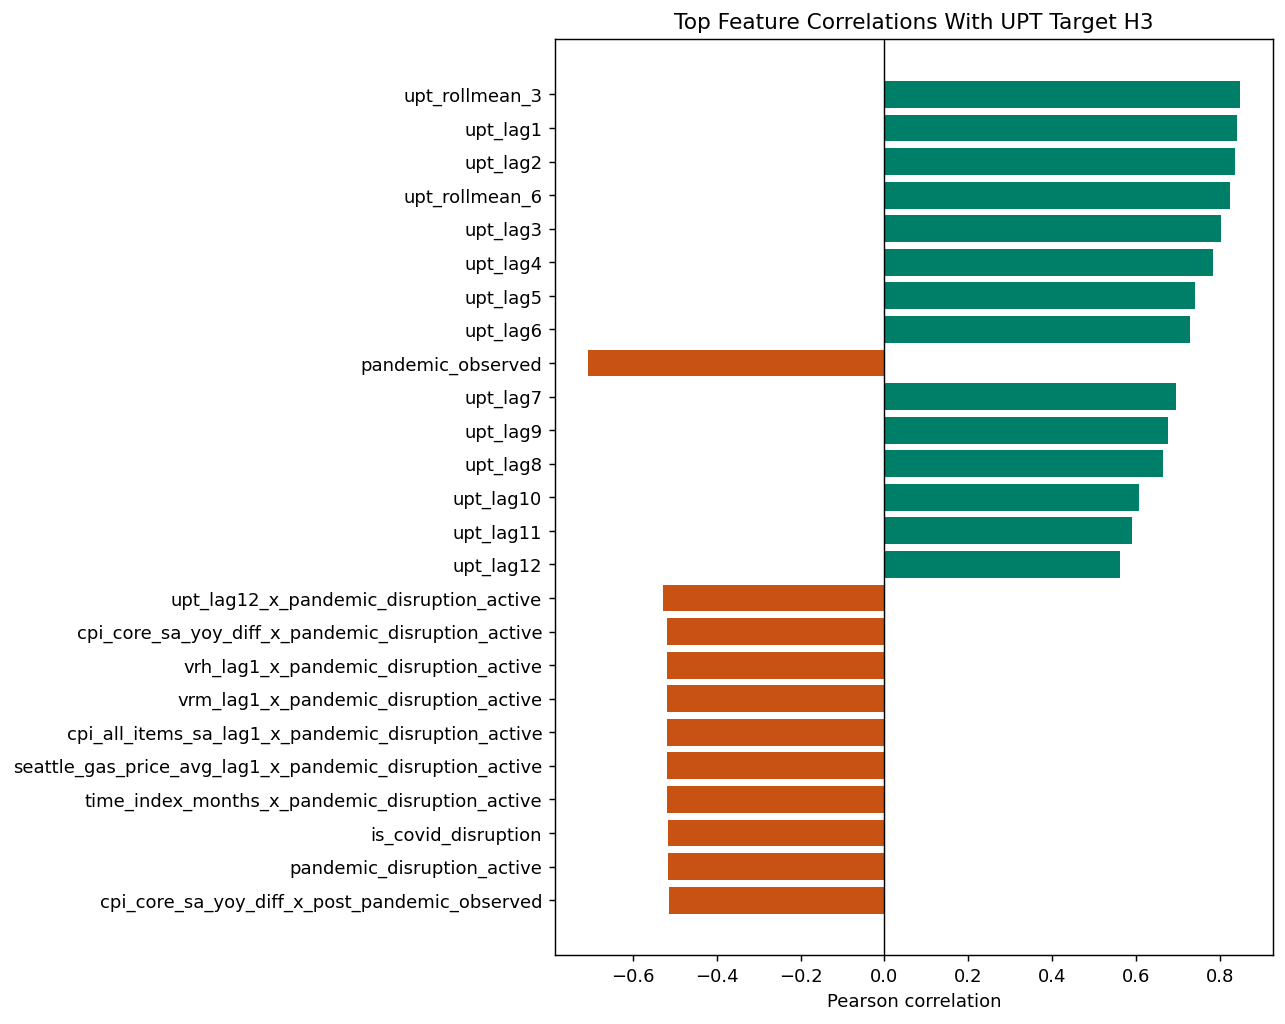

In [20]:
top_corr = target_corr.sort_values("abs_corr", ascending=False).head(25).sort_values("abs_corr")
fig, ax = plt.subplots(figsize=(10, 8))
colors = np.where(top_corr["corr_with_target"] >= 0, "#007f68", "#c85214")
ax.barh(top_corr["feature"], top_corr["corr_with_target"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Top Feature Correlations With UPT Target H{HORIZON}")
ax.set_xlabel("Pearson correlation")
plt.tight_layout()

In [21]:
target_corr.groupby("category").agg(
    features=("feature", "count"),
    max_abs_corr=("abs_corr", "max"),
    median_abs_corr=("abs_corr", "median"),
).sort_values("max_abs_corr", ascending=False).round(4)

,features,max_abs_corr,median_abs_corr
category,,,
rolling,14,0.8487,0.1946
lag,63,0.8418,0.2511
regime,37,0.7080,0.4903
change_rate,8,0.4644,0.3106
base_source,12,0.3872,0.2210
interaction,3,0.3854,0.3143
income,1,0.2943,0.2943
time_seasonality,8,0.2565,0.0385


## Redundancy And Collinearity Screen

Many features are intentionally related: lags, rolling means, YoY changes, and interactions can overlap. This screen identifies highly correlated feature pairs among non-target numeric features so we can decide later where correlation pruning is useful.

In [22]:
# Keep the pairwise screen bounded and interpretable by focusing on features with target signal.
collinearity_features = target_corr.sort_values("abs_corr", ascending=False).head(60)["feature"].tolist()
corr_matrix = modelable[collinearity_features].corr().abs()
upper_mask = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
pairs = corr_matrix.where(upper_mask).stack().reset_index()
pairs.columns = ["feature_a", "feature_b", "abs_corr"]
high_corr_pairs = pairs.query("abs_corr >= 0.95").sort_values("abs_corr", ascending=False)
high_corr_pairs.head(50).round(4)

,feature_a,feature_b,abs_corr
1764,months_since_covid_impact,months_since_pandemic_observed,1.0000
1274,post_pandemic_observed,is_post_covid,1.0000
1734,king_county_monthly_household_income_prior_year,king_county_median_household_income_prior_year,1.0000
1067,pandemic_disruption_active,is_covid_disruption,1.0000
867,vrh_lag1_x_pandemic_disruption_active,vrm_lag1_x_pandemic_disruption_active,1.0000
952,cpi_all_items_sa_lag1_x_pandemic_disruption_active,pandemic_disruption_active,1.0000
953,cpi_all_items_sa_lag1_x_pandemic_disruption_active,is_covid_disruption,1.0000
951,cpi_all_items_sa_lag1_x_pandemic_disruption_active,time_index_months_x_pandemic_disruption_active,0.9999
1029,time_index_months_x_pandemic_disruption_active,pandemic_disruption_active,0.9999
1030,time_index_months_x_pandemic_disruption_active,is_covid_disruption,0.9999


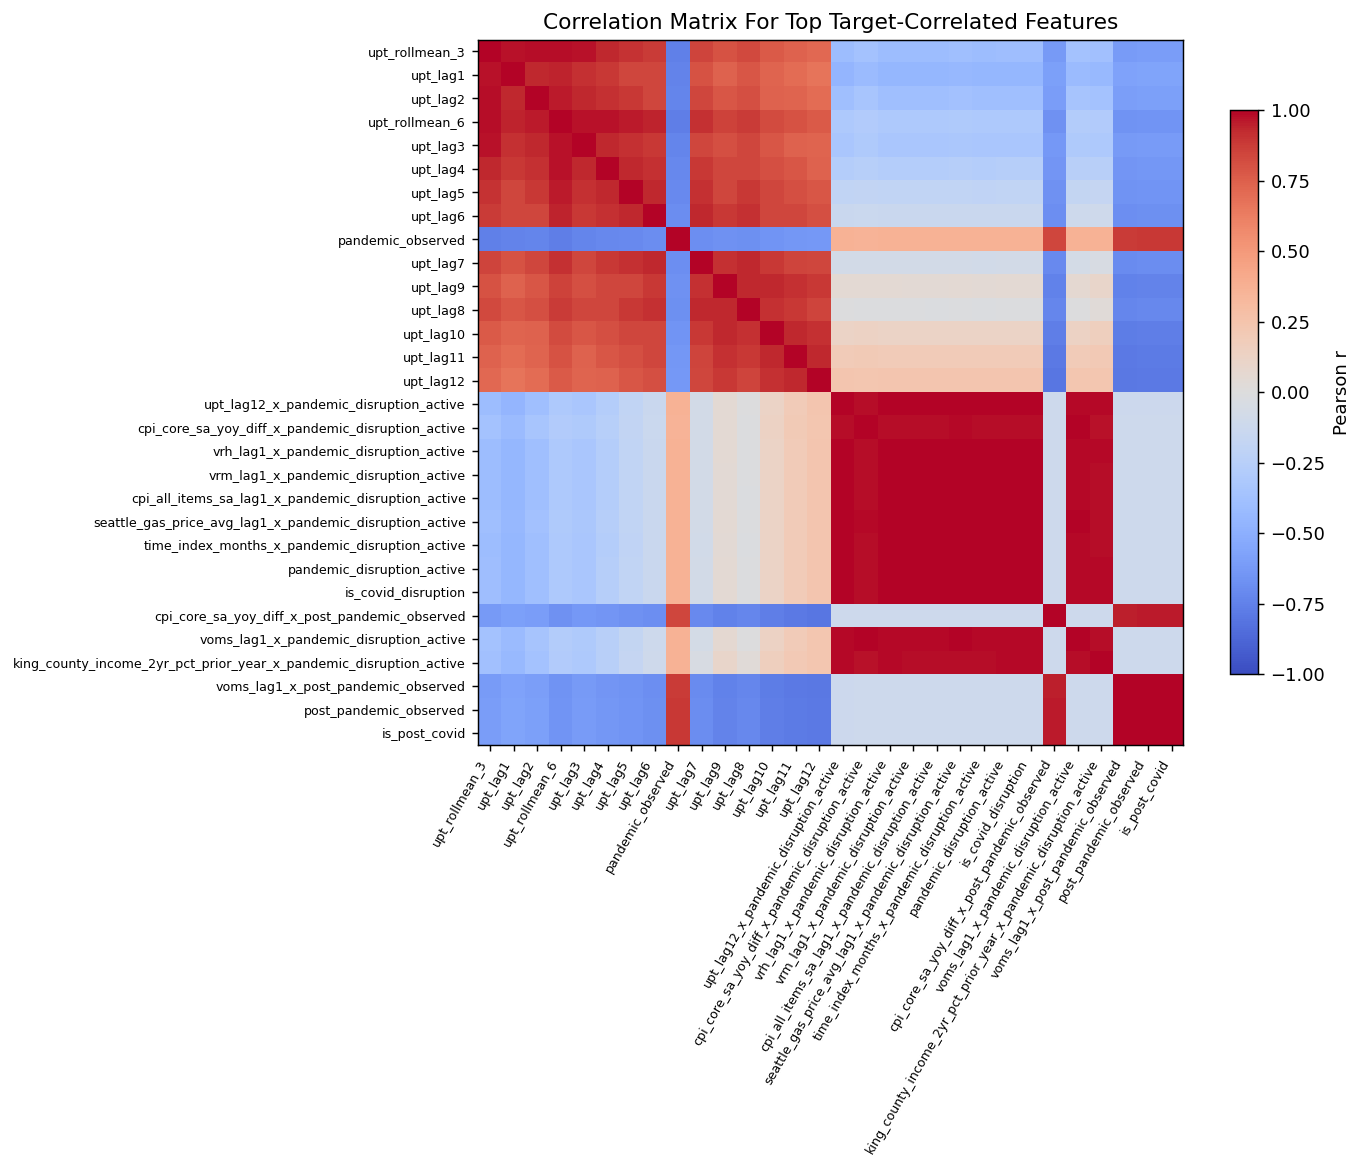

In [23]:
if collinearity_features:
    fig, ax = plt.subplots(figsize=(11, 9))
    subset = collinearity_features[:30]
    image = ax.imshow(modelable[subset].corr(), vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title("Correlation Matrix For Top Target-Correlated Features")
    ax.set_xticks(range(len(subset)), subset, rotation=60, ha="right", fontsize=7)
    ax.set_yticks(range(len(subset)), subset, fontsize=7)
    fig.colorbar(image, ax=ax, shrink=0.8, label="Pearson r")
    plt.tight_layout()

## Regime And Calendar Feature Checks

These are small checks to confirm that the calculated regime and target-calendar columns are active where expected. These variables are especially important because the experiment explicitly tests COVID-era robustness and target-month seasonality.

In [24]:
regime_cols = [col for col in feature_df.columns if "pandemic" in col or "covid" in col]
calendar_cols = [col for col in feature_df.columns if col.startswith("month_") or col.startswith("target_month_") or col in {"month_num"}]

regime_summary = pd.DataFrame(
    [
        {
            "column": col,
            "active_rows_or_mean": float(pd.to_numeric(feature_df[col], errors="coerce").fillna(0).sum())
            if feature_df[col].dropna().isin([0, 1]).all()
            else float(pd.to_numeric(feature_df[col], errors="coerce").mean()),
            "min": pd.to_numeric(feature_df[col], errors="coerce").min(),
            "max": pd.to_numeric(feature_df[col], errors="coerce").max(),
        }
        for col in regime_cols
    ]
)
regime_summary

,column,active_rows_or_mean,min,max
0,pandemic_observed,73.0000,0.0000,1.0000
1,pandemic_disruption_active,12.0000,0.0000,1.0000
2,post_pandemic_observed,61.0000,0.0000,1.0000
3,months_since_pandemic_observed,9.5564,0.0000,72.0000
4,is_covid_disruption,12.0000,0.0000,1.0000
5,is_post_covid,61.0000,0.0000,1.0000
6,months_since_covid_impact,9.5564,0.0000,72.0000
7,upt_lag1_x_pandemic_disruption_active,"156,712.6679",0.0000,"8,305,939.0000"
8,upt_lag1_x_post_pandemic_observed,"1,163,212.2701",0.0000,"7,027,582.0000"
9,upt_lag3_x_pandemic_disruption_active,"197,853.2463",0.0000,"8,705,965.0000"


In [25]:
calendar_check = feature_df[[DATE_COL, "month_num", f"target_date_h{HORIZON}", f"target_month_num_h{HORIZON}"]].copy()
calendar_check["actual_target_month_num"] = pd.to_datetime(calendar_check[f"target_date_h{HORIZON}"]).dt.month
calendar_check["target_month_match"] = calendar_check[f"target_month_num_h{HORIZON}"] == calendar_check["actual_target_month_num"]
calendar_check.tail(15)

,date,month_num,target_date_h3,target_month_num_h3,actual_target_month_num,target_month_match
260,2025-01-01,1,2025-04-01,4,4,True
261,2025-02-01,2,2025-05-01,5,5,True
262,2025-03-01,3,2025-06-01,6,6,True
263,2025-04-01,4,2025-07-01,7,7,True
264,2025-05-01,5,2025-08-01,8,8,True
265,2025-06-01,6,2025-09-01,9,9,True
266,2025-07-01,7,2025-10-01,10,10,True
267,2025-08-01,8,2025-11-01,11,11,True
268,2025-09-01,9,2025-12-01,12,12,True
269,2025-10-01,10,2026-01-01,1,1,True


## Initial Takeaways

- The calculated feature table is the modeling-ready version of the integrated data: it adds H3 target rows, target-month context, lags, rolling summaries, YoY/change features, regime flags, imputation indicators, and interaction terms.
- The last three rows naturally have missing H3 targets because their future target months are not observed yet.
- Feature families grow from compact historical baselines to broader service/economic/income/regime hypotheses.
- Correlation and collinearity screens are diagnostic only. Actual feature usefulness still needs rolling as-of evaluation and model-family-specific selection policies.

## Next EDA Ideas

- Compare pre-COVID, COVID shock, recovery, and recent-period feature distributions.
- Add Spearman target screens alongside Pearson for non-linear monotonic relationships.
- Add rolling-window correlations to check relationship stability through the COVID break.
- Build dashboard-ready callouts for calculated feature families once the notebook findings settle.